# Librerías

In [142]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
import seaborn as sns

# Librerías adicionales utilizadas
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler, StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.model_selection import train_test_split,  cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.neighbors import KNeighborsClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import RidgeCV
from sklearn.dummy import DummyRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

from sklearn.mixture import GaussianMixture
import seaborn as sns
from sklearn.metrics import silhouette_score

from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import roc_auc_score, brier_score_loss, roc_curve
import joblib

from sklearn.model_selection import KFold
from sklearn.ensemble import RandomForestRegressor
from sklearn.base import clone
from econml.dml import LinearDML

# Clusters con GMM

## Obtenemos del dataset filtrado y lo dividmos en variables objetivo, de tratamiento y confusoras

In [143]:
!wget -q https://raw.githubusercontent.com/ClemoAcevedo/hsls09-causal-impact/refs/heads/main/Entrega%20Avance/hsls09_master_clean.csv

In [144]:
df_master_clean = pd.read_csv("hsls09_master_clean.csv")

In [145]:
df_master_clean.head()

,STU_ID,X3TGPA9TH,X1TXMTH,X1PAREDU,X1FAMINCOME,X1POVERTY,X1POVERTY130,X1PAR1EMP,X1SEX,X1RACE,...,X1SEX_1.0,X1SEX_2.0,X1RACE_1.0,X1RACE_2.0,X1RACE_3.0,X1RACE_4.0,X1RACE_5.0,X1RACE_6.0,X1RACE_7.0,X1RACE_8.0
0,10001,3.5,0.8304,5.0,10.0,0.0,0.0,4.0,1.0,8.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,10002,4.0,-0.2956,3.0,3.0,0.0,0.0,3.0,2.0,8.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,10003,3.5,1.2997,7.0,6.0,0.0,0.0,4.0,2.0,3.0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
3,10004,3.5,-0.1427,4.0,5.0,0.0,0.0,2.0,2.0,8.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,10005,3.5,1.1405,4.0,9.0,0.0,0.0,4.0,1.0,8.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [146]:
objetivo = ['X3TGPAACAD']
tratamiento = ['X3TCREDADV', 'X3TCREDHON', 'A1G9STUDY']
features_X = [
    # confusores
    'X3TGPA9TH', 'X1TXMTH', 'X5DUALCRSFLG',
    'X1PAREDU', 'X1FAMINCOME', 'X1POVERTY', 'X1POVERTY130', 'X1PAR1EMP', 'X1STDOB',

    # dummies de sexo
    'X1SEX_1.0', 'X1SEX_2.0',

    # dummies de raza
    'X1RACE_1.0', 'X1RACE_2.0', 'X1RACE_3.0', 'X1RACE_4.0',
    'X1RACE_5.0', 'X1RACE_6.0', 'X1RACE_7.0', 'X1RACE_8.0'
]

print(df_master_clean[['X3TGPAACAD'] + tratamiento].dtypes)

for col in ['X3TGPAACAD'] + tratamiento:
    print(f"{col}: {df_master_clean[col].nunique()} valores únicos")
    print(df_master_clean[col].value_counts(dropna=False).head())

df_master_clean[['X3TGPAACAD'] + tratamiento].describe()



X3TGPAACAD    float64
X3TCREDADV    float64
X3TCREDHON    float64
A1G9STUDY     float64
dtype: object
X3TGPAACAD: 9 valores únicos
X3TGPAACAD
3.0    4417
2.5    4091
3.5    3999
2.0    3397
1.5    2304
Name: count, dtype: int64
X3TCREDADV: 31 valores únicos
X3TCREDADV
0.0    9163
1.0    3065
2.0    1660
NaN    1575
0.5    1160
Name: count, dtype: int64
X3TCREDHON: 35 valores únicos
X3TCREDHON
0.0    13189
1.0     1597
NaN     1575
2.0     1070
3.0      726
Name: count, dtype: int64
A1G9STUDY: 2 valores únicos
A1G9STUDY
0.0    11860
1.0     8481
NaN     3162
Name: count, dtype: int64


,X3TGPAACAD,X3TCREDADV,X3TCREDHON,A1G9STUDY
count,21858.000000,21928.000000,21928.000000,20341.000000
mean,2.574675,2.089999,2.027818,0.416941
std,0.905145,3.181792,3.688540,0.493065
min,0.250000,0.000000,0.000000,0.000000
25%,2.000000,0.000000,0.000000,0.000000
50%,2.500000,1.000000,0.000000,0.000000
75%,3.500000,3.000000,2.000000,1.000000
max,4.000000,17.000000,19.000000,1.000000


In [147]:
# Tratamiento de nans en tratamiento y objetivo

df_master_clean['X3TCREDADV'] = df_master_clean['X3TCREDADV'].fillna(0)
df_master_clean['X3TCREDHON'] = df_master_clean['X3TCREDHON'].fillna(0)
df_master_clean['A1G9STUDY'] = df_master_clean['A1G9STUDY'].fillna(0)


In [148]:
# Eliminar filas donde el objetivo tienen NaN
df_model = df_master_clean.dropna(subset=objetivo)

# Variable Objetivo
y = df_model[objetivo].copy()

# Variables de tratamiento
t = df_model[tratamiento].copy()

# Variables confusoras
X = df_model[features_X].copy()

print(f"Dataset listo para modelar (filas sin NaN en target): {df_model.shape}")
print(f"Dimensiones de X (confusoras): {X.shape}")
print(f"Dimensiones de y (objetivo): {y.shape}")
print(f"Dimensiones de t (tratamiento): {t.shape}")
print(f"Total de features: {len(features_X)}")

Dataset listo para modelar (filas sin NaN en target): (21858, 31)
Dimensiones de X (confusoras): (21858, 19)
Dimensiones de y (objetivo): (21858, 1)
Dimensiones de t (tratamiento): (21858, 3)
Total de features: 19


In [149]:
# primero, revisamos si X tiene nulos que necesiten cuidado
nulos_en_x = X.isnull().sum()
nulos_en_x = nulos_en_x[nulos_en_x > 0].sort_values(ascending=False)

if nulos_en_x.empty:
    print("No se encontraron NaNs en las features (X).")
else:
    print("Features con NaNs que requieren imputación:")
    print(nulos_en_x)
    print("\n")

Features con NaNs que requieren imputación:
X5DUALCRSFLG    9510
X1POVERTY130    6128
X1POVERTY       6128
X1PAR1EMP       6102
X1FAMINCOME     6102
X1PAREDU        6084
X1TXMTH         1883
X3TGPA9TH        730
X1STDOB          173
dtype: int64




In [150]:
# Imputamos X5DUALCRSFLG con 0 (no tomó doble titulación)
X['X5DUALCRSFLG'] = X['X5DUALCRSFLG'].fillna(0)

# Imputamos el resto de las variables confusoras con la mediana
imputer = SimpleImputer(strategy='median')
X_imputed = imputer.fit_transform(X)

print("Datos imputados (NaNs rellenados con la mediana).")

# Escalamos con StandardScaler
scaler = StandardScaler()
X_ready = scaler.fit_transform(X_imputed)

print("Datos escalados con StandardScaler (media=0, std=1).")
print("\nPrimeras 5 filas de X_ready (verificación):")
print(X_ready[:5])


Datos imputados (NaNs rellenados con la mediana).
Datos escalados con StandardScaler (media=0, std=1).

Primeras 5 filas de X_ready (verificación):
[[ 0.84929971  0.84925438  1.02191574  1.3821718   2.14529034 -0.35969284
  -0.4320988   0.60896996  0.71647246  0.9839336  -0.98348344 -0.08256594
  -0.30191746 -0.33815863 -0.13495926 -0.40675449 -0.30173701 -0.06745251
   0.96643364]
 [ 1.40293643 -0.36923073  1.02191574 -0.15958581 -0.56266661 -0.35969284
  -0.4320988  -0.5514228   0.8611276  -1.01632874  1.01679394 -0.08256594
  -0.30191746 -0.33815863 -0.13495926 -0.40675449 -0.30173701 -0.06745251
   0.96643364]
 [ 0.84929971  1.3571008   1.02191574  2.9239294   0.59788637 -0.35969284
  -0.4320988   0.60896996  0.78076363 -1.01632874  1.01679394 -0.08256594
  -0.30191746  2.95719198 -0.13495926 -0.40675449 -0.30173701 -0.06745251
  -1.03473219]
 [ 0.84929971 -0.20377214 -1.10191485  0.61129299  0.21103538 -0.35969284
  -0.4320988  -1.71181556  0.76469084 -1.01632874  1.01679394 -0.08

In [151]:
# Revisar si hay algún NaN
has_nan = np.isnan(X_ready).any()
print("¿Hay NaNs en X_ready?", has_nan)

# Contar cuántos NaNs hay (opcional)
num_nan = np.isnan(X_ready).sum()
print("Número total de NaNs en X_ready:", num_nan)


¿Hay NaNs en X_ready? False
Número total de NaNs en X_ready: 0


## Aplicar GMM

In [152]:
# Rango de valores de K a evaluar
n_range = range(2, 12)

aic_values = []
bic_values = []

for k in n_range:
    gmm = GaussianMixture(
        n_components=k,
        covariance_type='full',
        random_state=86
    )
    gmm.fit(X_ready)
    labels = gmm.predict(X_ready)

    aic_values.append(gmm.aic(X_ready))
    bic_values.append(gmm.bic(X_ready))

    sil = silhouette_score(X_ready, labels)
    print(f"Silhouette Score (K={k}): {sil:.4f}")

print("AIC:", aic_values)
print("BIC:", bic_values)

Silhouette Score (K=2): 0.2745
Silhouette Score (K=3): 0.2547
Silhouette Score (K=4): 0.1601
Silhouette Score (K=5): 0.1279
Silhouette Score (K=6): 0.1216
Silhouette Score (K=7): 0.1464
Silhouette Score (K=8): 0.2070
Silhouette Score (K=9): 0.1716
Silhouette Score (K=10): 0.0683
Silhouette Score (K=11): 0.1188
AIC: [np.float64(-492641.8647588146), np.float64(-629806.5444383769), np.float64(-1118504.0200634273), np.float64(-1172263.1588021875), np.float64(-1440208.4018650788), np.float64(-1443772.2961350526), np.float64(-1426952.3086973203), np.float64(-1794691.5403794153), np.float64(-1876147.3799696222), np.float64(-1981883.8493466133)]
BIC: [np.float64(-489293.0817292615), np.float64(-624779.3737329141), np.float64(-1111798.4616820547), np.float64(-1163879.2127449054), np.float64(-1430146.068131887), np.float64(-1432031.574725951), np.float64(-1413533.199612309), np.float64(-1779594.0436184942), np.float64(-1859371.4955327916), np.float64(-1963429.5772338728)]


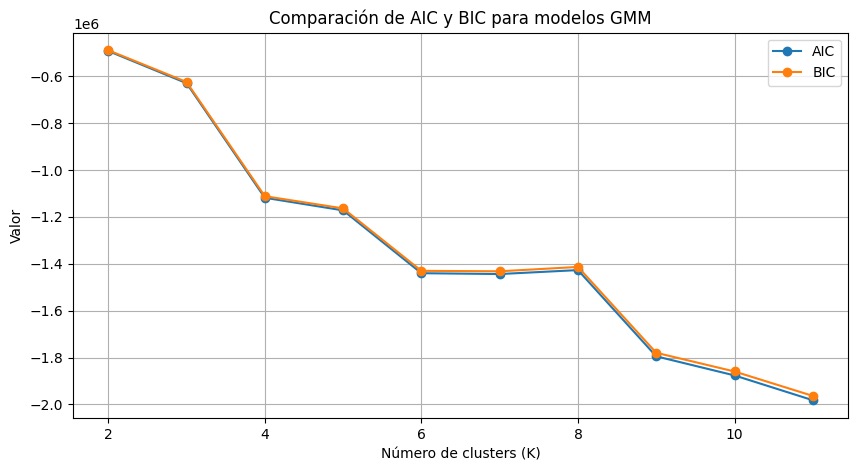

In [153]:
# Graficamos AIC Y BIC
plt.figure(figsize=(10,5))
plt.plot(n_range, aic_values, marker='o', label='AIC')
plt.plot(n_range, bic_values, marker='o', label='BIC')
plt.xlabel("Número de clusters (K)")
plt.ylabel("Valor")
plt.title("Comparación de AIC y BIC para modelos GMM")
plt.legend()
plt.grid(True)
plt.show()

Vemos que para k=6 a 8 se los valores de AIC y BIC se estabilizan, ade-as se alcanza un máximo de silhouette Score en k=8, por lo que usamos ese valor

In [154]:
# Aplicar GMM

gm = GaussianMixture(n_components=8, random_state=86, covariance_type="full")
gm.fit(X_ready)
labels = gm.predict(X_ready)
probs = gm.predict_proba(X_ready)

In [155]:
(unique, counts) = np.unique(labels, return_counts=True)
print(f'Datos por cluster: {list(zip(unique, counts))}')

print(f'Probabilidades de pertetencia {probs[:5]}')

Datos por cluster: [(np.int64(0), np.int64(2399)), (np.int64(1), np.int64(2461)), (np.int64(2), np.int64(6553)), (np.int64(3), np.int64(1829)), (np.int64(4), np.int64(6768)), (np.int64(5), np.int64(1601)), (np.int64(6), np.int64(99)), (np.int64(7), np.int64(148))]
Probabilidades de pertetencia [[0. 0. 0. 0. 1. 0. 0. 0.]
 [0. 0. 1. 0. 0. 0. 0. 0.]
 [0. 0. 0. 1. 0. 0. 0. 0.]
 [0. 0. 1. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1. 0. 0. 0.]]


Vemos que los clusters 6 y 7 tienen muy pocos datos, por lo que de los 8 clusters nos quedaremos con los 6 primeros

In [156]:
# df_model: DataFrame original con outcome, treatment y confusores
# X_ready: array numpy imputado y escalado de las confusoras
# t: DataFrame de tratamientos
# y: Series del outcome
# labels: clusters ya asignados

# Convertimos X_ready a DataFrame para unirlo
X_ready_df = pd.DataFrame(X_ready, columns=features_X, index=df_model.index)

# Creamos df_clustered uniendo outcome, tratamientos, confusores imputados y clusters
df_clustered = pd.concat([y, t, X_ready_df], axis=1)
df_clustered["Cluster"] = labels

# Si quieres eliminar clusters pequeños
df_clustered = df_clustered[~df_clustered['Cluster'].isin([6,7])]

# Verificamos si quedaron NaNs
print(df_clustered.isnull().sum().sum())  # debería ser 0


0


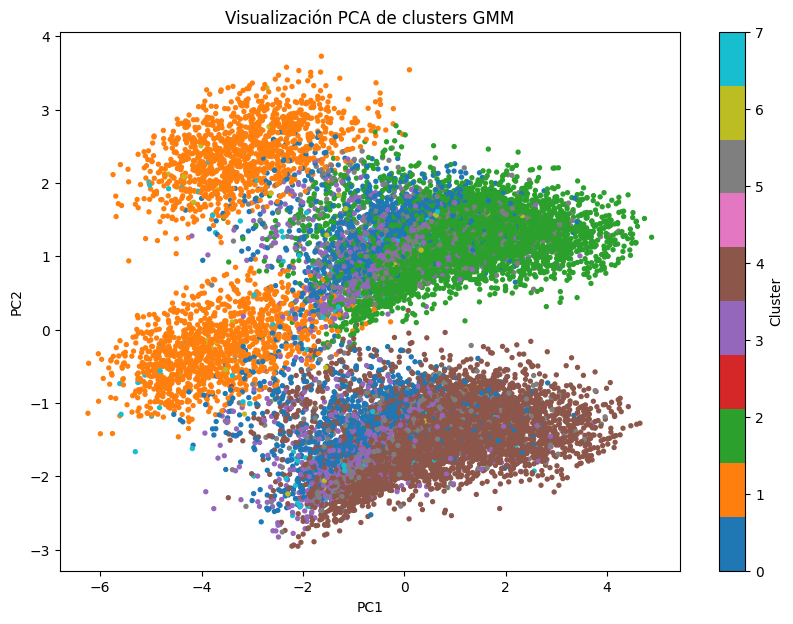

In [157]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_ready)

plt.figure(figsize=(10,7))
plt.scatter(X_pca[:,0], X_pca[:,1], c=labels, s=8, cmap="tab10")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Visualización PCA de clusters GMM")
plt.colorbar(label="Cluster")
plt.show()

## Análisis de Clusters

In [158]:
cols_resumen = features_X + tratamiento + ['X3TGPAACAD']

cluster_summary = df_clustered.groupby("Cluster")[cols_resumen].mean()

print("---------------- Estadísticas por Cluster (Media) ----------------")
display(cluster_summary)


---------------- Estadísticas por Cluster (Media) ----------------


,X3TGPA9TH,X1TXMTH,X5DUALCRSFLG,X1PAREDU,X1FAMINCOME,X1POVERTY,X1POVERTY130,X1PAR1EMP,X1STDOB,X1SEX_1.0,...,X1RACE_3.0,X1RACE_4.0,X1RACE_5.0,X1RACE_6.0,X1RACE_7.0,X1RACE_8.0,X3TCREDADV,X3TCREDHON,A1G9STUDY,X3TGPAACAD
Cluster,,,,,,,,,,,,,,,,,,,,,
0,-0.225088,-0.225135,-0.064050,-0.213248,-0.072129,-0.359693,-0.167649,0.045461,-0.012766,-0.014113,...,-0.338159,-0.134959,2.458485,-0.301737,-0.067453,-1.034732,1.722593,1.687578,0.330971,2.379637
1,-0.426022,-0.401828,-0.290124,-0.809241,-1.169744,2.780150,2.314286,-0.902700,-0.243774,-0.008476,...,0.216199,0.064309,0.412883,0.025911,-0.067453,-0.328917,1.269809,1.023771,0.343763,2.177570
2,0.360633,0.173053,0.162077,0.185916,0.243917,-0.359693,-0.334448,0.107839,0.149142,-1.016329,...,-0.338159,0.049252,-0.406754,-0.301737,-0.067453,0.533708,2.569358,2.722951,0.368381,2.941744
3,-0.425972,-0.387450,-0.011550,0.006054,-0.105171,-0.359693,-0.226383,0.228940,-0.060391,0.029188,...,2.957192,-0.134959,-0.406754,-0.301737,-0.067453,-1.034732,1.223619,1.321214,0.367414,2.190268
4,0.028006,0.173701,-0.020962,0.184849,0.240644,-0.359693,-0.337956,0.125302,-0.042247,0.982456,...,-0.338159,0.050089,-0.406754,-0.301737,-0.067453,0.531783,2.298094,2.097665,0.373375,2.561650
5,-0.055850,0.026433,0.008420,0.049384,0.056875,-0.359693,-0.288004,0.095817,0.046013,-0.004328,...,-0.338159,-0.134959,-0.406754,3.314144,-0.067453,-1.034732,2.167395,1.932230,0.347283,2.527639


In [159]:
print("---------------- Tamaño de cada cluster ----------------")
print(df_clustered["Cluster"].value_counts().sort_index())

---------------- Tamaño de cada cluster ----------------
Cluster
0    2399
1    2461
2    6553
3    1829
4    6768
5    1601
Name: count, dtype: int64


In [160]:
cluster_profile = df_clustered.groupby("Cluster")[cols_resumen].agg(["mean", "std"])
display(cluster_profile)


cluster_norm = df_clustered.groupby("Cluster")[cols_resumen].mean()
cluster_norm = (cluster_norm - cluster_norm.mean()) / cluster_norm.std()
display(cluster_norm)

X3TGPA9TH             X1TXMTH           X5DUALCRSFLG            \
             mean       std      mean       std         mean       std   
Cluster                                                                  
0       -0.225088  0.972644 -0.225135  0.976380    -0.064050  1.010221   
1       -0.426022  1.033758 -0.401828  0.949585    -0.290124  0.993425   
2        0.360633  0.901319  0.173053  0.933054     0.162077  0.956016   
3       -0.425972  0.973555 -0.387450  0.928554    -0.011550  1.028243   
4        0.028006  0.956163  0.173701  1.013342    -0.020962  1.002038   
5       -0.055850  1.013781  0.026433  0.989159     0.008420  1.003490   

         X1PAREDU           X1FAMINCOME            ... X1RACE_8.0            \
             mean       std        mean       std  ...       mean       std   
Cluster                                            ...                        
0       -0.213248  0.918637   -0.072129  0.839121  ...  -1.034732  0.000000   
1       -0.809241  0.794359   -1.169744  0.195683  ...  -0.328917  0.956373   
2        0.185916  0.994501    0.243917  1.004814  ...   0.533708  0.823898   
3        0.006054  0.843484   -0.105171  0.757394  ...  -1.034732  0.000000   
4        0.184849  0.997074    0.240644  1.003539  ...   0.531783  0.825219   
5        0.049384  0.938280    0.056875  0.878531  ...  -1.034732  0.000000   

        X3TCREDADV           X3TCREDHON           A1G9STUDY            \
              mean       std       mean       std      mean       std   
Cluster                                                                 
0         1.722593  2.839620   1.687578  3.422080  0.330971  0.470661   
1         1.269809  2.436498   1.023771  2.621003  0.343763  0.475060   
2         2.569358  3.448165   2.722951  4.188920  0.368381  0.482402   
3         1.223619  2.244253   1.321214  2.916042  0.367414  0.482232   
4         2.298094  3.351735   2.097665  3.736578  0.373375  0.483736   
5         2.167395  3.249773   1.932230  3.472472  0.347283  0.476255   

        X3TGPAACAD            
              mean       std  
Cluster                       
0         2.379637  0.854618  
1         2.177570  0.914240  
2         2.941744  0.811676  
3         2.190268  0.852669  
4         2.561650  0.884656  
5         2.527639  0.889729  

[6 rows x 46 columns]

,X3TGPA9TH,X1TXMTH,X5DUALCRSFLG,X1PAREDU,X1FAMINCOME,X1POVERTY,X1POVERTY130,X1PAR1EMP,X1STDOB,X1SEX_1.0,...,X1RACE_3.0,X1RACE_4.0,X1RACE_5.0,X1RACE_6.0,X1RACE_7.0,X1RACE_8.0,X3TCREDADV,X3TCREDHON,A1G9STUDY,X3TGPAACAD
Cluster,,,,,,,,,,,,,,,,,,,,,
0,-0.334853,-0.444113,-0.191176,-0.301685,0.117557,-0.408248,-0.309832,0.225887,0.111824,-0.013990,...,-0.486504,-0.911660,1.956607,-0.451617,-0.912871,-0.832873,-0.273075,-0.183200,-1.430663,-0.292876
1,-1.000765,-1.107643,-1.733724,-1.880735,-1.958940,2.041241,2.037318,-2.020305,-1.660999,-0.005075,...,-0.066165,1.005555,0.178609,-0.226481,-0.912871,0.085466,-1.083580,-1.288839,-0.675280,-1.002073
2,1.606276,1.051189,1.351734,0.755877,0.715461,-0.408248,-0.467572,0.373660,1.354352,-1.598981,...,-0.486504,0.860688,-0.533804,-0.451617,-0.912871,1.207829,1.242674,1.541321,0.778514,1.679955
3,-1.000599,-1.053649,0.167041,0.279344,0.055046,-0.408248,-0.365376,0.660548,-0.253664,0.054491,...,2.012182,-0.911660,-0.533804,-0.451617,-0.912871,-0.832873,-1.166262,-0.793417,0.721409,-0.957508
4,0.503924,1.053624,0.102822,0.753052,0.709267,-0.408248,-0.470889,0.415029,-0.114425,1.562071,...,-0.486504,0.868737,-0.533804,-0.451617,-0.912871,1.205325,0.757100,0.499843,1.073417,0.345936
5,0.226017,0.500592,0.303302,0.394146,0.361609,-0.408248,-0.423650,0.345180,0.562912,0.001484,...,-0.486504,-0.911660,-0.533804,2.032948,-0.912871,-0.832873,0.523143,0.224293,-0.467397,0.226566


Resumen del contenido de cada Cluster


In [161]:
for c in sorted(df_clustered["Cluster"].unique()):
    print(f"\n-------------- Cluster {c} --------------")

    temp = cluster_summary.loc[c]

    print(f"- Tamaño: {df_clustered[df_clustered['Cluster']==c].shape[0]} estudiantes")

    # Confusores
    print("\nConfusores relevantes:")
    for var in features_X:
        valor = temp[var]
        if valor > df_clustered[var].mean():
            print(f"  - {var}: más alto que el promedio")
        else:
            print(f"  - {var}: más bajo que el promedio")

    # Tratamiento
    print("\nTratamientos:")
    for var in tratamiento:
        valor = temp[var]
        promedio = df_clustered[var].mean()
        print(f"  - {var}: {valor:.3f} (promedio={promedio:.3f})")

    # Outcome
    print(f"\nRendimiento académico (GPA X3TGPAACAD): {temp['X3TGPAACAD']:.3f}")


-------------- Cluster 0 --------------
- Tamaño: 2399 estudiantes

Confusores relevantes:
  - X3TGPA9TH: más bajo que el promedio
  - X1TXMTH: más bajo que el promedio
  - X5DUALCRSFLG: más bajo que el promedio
  - X1PAREDU: más bajo que el promedio
  - X1FAMINCOME: más bajo que el promedio
  - X1POVERTY: más bajo que el promedio
  - X1POVERTY130: más bajo que el promedio
  - X1PAR1EMP: más alto que el promedio
  - X1STDOB: más bajo que el promedio
  - X1SEX_1.0: más bajo que el promedio
  - X1SEX_2.0: más alto que el promedio
  - X1RACE_1.0: más bajo que el promedio
  - X1RACE_2.0: más bajo que el promedio
  - X1RACE_3.0: más bajo que el promedio
  - X1RACE_4.0: más bajo que el promedio
  - X1RACE_5.0: más alto que el promedio
  - X1RACE_6.0: más bajo que el promedio
  - X1RACE_7.0: más bajo que el promedio
  - X1RACE_8.0: más bajo que el promedio

Tratamientos:
  - X3TCREDADV: 1.723 (promedio=2.099)
  - X3TCREDHON: 1.688 (promedio=2.041)
  - A1G9STUDY: 0.331 (promedio=0.361)

Rendi

# Modelos de nuisance (residualización)

In [162]:
df_clustered.head()

,X3TGPAACAD,X3TCREDADV,X3TCREDHON,A1G9STUDY,X3TGPA9TH,X1TXMTH,X5DUALCRSFLG,X1PAREDU,X1FAMINCOME,X1POVERTY,...,X1SEX_2.0,X1RACE_1.0,X1RACE_2.0,X1RACE_3.0,X1RACE_4.0,X1RACE_5.0,X1RACE_6.0,X1RACE_7.0,X1RACE_8.0,Cluster
0,3.5,3.0,0.0,0.0,0.849300,0.849254,1.021916,1.382172,2.145290,-0.359693,...,-0.983483,-0.082566,-0.301917,-0.338159,-0.134959,-0.406754,-0.301737,-0.067453,0.966434,4
1,4.0,0.0,0.0,0.0,1.402936,-0.369231,1.021916,-0.159586,-0.562667,-0.359693,...,1.016794,-0.082566,-0.301917,-0.338159,-0.134959,-0.406754,-0.301737,-0.067453,0.966434,2
2,2.5,6.0,4.0,0.0,0.849300,1.357101,1.021916,2.923929,0.597886,-0.359693,...,1.016794,-0.082566,-0.301917,2.957192,-0.134959,-0.406754,-0.301737,-0.067453,-1.034732,3
3,4.0,5.0,10.5,0.0,0.849300,-0.203772,-1.101915,0.611293,0.211035,-0.359693,...,1.016794,-0.082566,-0.301917,-0.338159,-0.134959,-0.406754,-0.301737,-0.067453,0.966434,2
4,3.5,5.0,0.5,0.0,0.849300,1.184825,-1.101915,0.611293,1.758439,-0.359693,...,-0.983483,-0.082566,-0.301917,-0.338159,-0.134959,-0.406754,-0.301737,-0.067453,0.966434,4


In [163]:
# Separar variables
y = df_clustered[objetivo].values
T = df_clustered[tratamiento].values
X_features = df_clustered[features_X].values


In [164]:
# Iteramos por cluster dividiendo las variables
clusters = df_clustered['Cluster'].unique()

# Diccionarios para guardar los datos por cluster
y_clusters = {}
T_clusters = {}
X_clusters = {}

for c in clusters:
    # Subset del cluster
    df_c = df_clustered[df_clustered['Cluster'] == c]

    y_clusters[c] = df_c[objetivo].values
    T_clusters[c] = df_c[tratamiento].values
    X_clusters[c] = df_c[features_X].values


In [165]:

# VARS CONTINUAS
def tune_rf_regressor(X, y, random_state=86):
    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("rf", RandomForestRegressor(random_state=random_state))
    ])

    param_grid = {
        "rf__n_estimators": [100, 200],
        "rf__max_depth": [5, 10, None],
        "rf__min_samples_leaf": [5, 10],
        "rf__max_features": ["sqrt"]
    }

    cv = KFold(n_splits=3, shuffle=True, random_state=random_state)
    grid = GridSearchCV(pipe, param_grid, cv=cv, n_jobs=-1, scoring='r2', verbose=0)
    grid.fit(X, y)
    return grid.best_estimator_



# VARS BINARIAS
def tune_rf_classifier(X, y, random_state=86):
    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("rf", RandomForestClassifier(random_state=random_state, class_weight="balanced"))
    ])

    param_grid = {
        "rf__n_estimators": [100, 200],
        "rf__max_depth": [5, 10, None],
        "rf__min_samples_leaf": [5, 10],
        "rf__max_features": ["sqrt"]
    }

    cv = KFold(n_splits=3, shuffle=True, random_state=random_state)
    grid = GridSearchCV(pipe, param_grid, cv=cv, n_jobs=-1, scoring='roc_auc', verbose=0)
    grid.fit(X, y)
    return grid.best_estimator_



In [166]:
# Diccionarios para guardar los mejores modelos por cluster
best_model_y = {}
best_model_t = {treatment_name: {} for treatment_name in tratamiento}

for c in clusters:
    print(f"\n===== Cluster {c} =====")

    X_c = X_clusters[c]
    y_c = y_clusters[c]
    T_c = T_clusters[c]

    # Tunear modelo para Y (GPA, continua/discreta)
    best_model_y[c] = tune_rf_regressor(X_c, y_c.ravel())


    # Tunear modelos para cada tratamiento según tipo
    for i, treatment_name in enumerate(tratamiento):
        if treatment_name == "A1G9STUDY":
            # Binaria --- Classifier
            best_model_t[treatment_name][c] = tune_rf_classifier(X_c, T_c[:, i].ravel())

        else:
            # Continua/Discreta --- Regressor
            best_model_t[treatment_name][c] = tune_rf_regressor(X_c, T_c[:, i])




===== Cluster 4 =====

===== Cluster 2 =====

===== Cluster 3 =====

===== Cluster 0 =====

===== Cluster 1 =====

===== Cluster 5 =====


In [167]:
for c in clusters:
    X_c = X_clusters[c]
    y_c = y_clusters[c]
    T_c = T_clusters[c]

    print(f"Cluster {c}:")
    print("  NaNs en X:", np.isnan(X_c).sum())
    print("  NaNs en y:", np.isnan(y_c).sum())
    print("  NaNs en T:", np.isnan(T_c).sum())

Cluster 4:
  NaNs en X: 0
  NaNs en y: 0
  NaNs en T: 0
Cluster 2:
  NaNs en X: 0
  NaNs en y: 0
  NaNs en T: 0
Cluster 3:
  NaNs en X: 0
  NaNs en y: 0
  NaNs en T: 0
Cluster 0:
  NaNs en X: 0
  NaNs en y: 0
  NaNs en T: 0
Cluster 1:
  NaNs en X: 0
  NaNs en y: 0
  NaNs en T: 0
Cluster 5:
  NaNs en X: 0
  NaNs en y: 0
  NaNs en T: 0


# DML

In [168]:
# Efecto por cluster y por tratamiento individual
effects_clusters = {}  # guardaremos resultados por cluster y tratamiento

for c in clusters:
    print(f"\n===== Cluster {c} =====")

    y_c = y_clusters[c].ravel()
    X_c = X_clusters[c]

    effects_clusters[c] = {}  # diccionario por tratamiento

    for i, treatment_name in enumerate(tratamiento):
        print(f"\n--- Tratamiento: {treatment_name} ---")
        T_c_i = T_clusters[c][:, i]  # tomar solo la columna de este tratamiento

        # Seleccionar modelo correspondiente
        model_t_i = best_model_t[treatment_name][c]

        # DML para un solo tratamiento
        dml = LinearDML(
            model_y=best_model_y[c],
            model_t=model_t_i,
            discrete_treatment=(treatment_name=="A1G9STUDY"),
            random_state=86,
            cv=3
        )

        # Fit
        dml.fit(y_c, T_c_i, X=X_c)

        # Guardar efecto individual
        effects_clusters[c][treatment_name] = dml.effect(X_c)

        # Efecto promedio
        print(f"Efecto promedio: {effects_clusters[c][treatment_name].mean():.3f}")




===== Cluster 4 =====

--- Tratamiento: X3TCREDADV ---


/usr/local/lib/python3.12/dist-packages/econml/sklearn_extensions/linear_model.py:1815: UserWarning: Co-variance matrix is underdetermined. Inference will be invalid!
  warnings.warn("Co-variance matrix is underdetermined. Inference will be invalid!")


Efecto promedio: 0.023

--- Tratamiento: X3TCREDHON ---


/usr/local/lib/python3.12/dist-packages/econml/sklearn_extensions/linear_model.py:1815: UserWarning: Co-variance matrix is underdetermined. Inference will be invalid!
  warnings.warn("Co-variance matrix is underdetermined. Inference will be invalid!")


Efecto promedio: 0.023

--- Tratamiento: A1G9STUDY ---


...

/usr/local/lib/python3.12/dist-packages/econml/sklearn_extensions/linear_model.py:1815: UserWarning: Co-variance matrix is underdetermined. Inference will be invalid!
  warnings.warn("Co-variance matrix is underdetermined. Inference will be invalid!")


Efecto promedio: 0.038

--- Tratamiento: X3TCREDHON ---


/usr/local/lib/python3.12/dist-packages/econml/sklearn_extensions/linear_model.py:1815: UserWarning: Co-variance matrix is underdetermined. Inference will be invalid!
  warnings.warn("Co-variance matrix is underdetermined. Inference will be invalid!")


Efecto promedio: 0.029

--- Tratamiento: A1G9STUDY ---
Efecto promedio: -0.010


/usr/local/lib/python3.12/dist-packages/econml/sklearn_extensions/linear_model.py:1815: UserWarning: Co-variance matrix is underdetermined. Inference will be invalid!
  warnings.warn("Co-variance matrix is underdetermined. Inference will be invalid!")


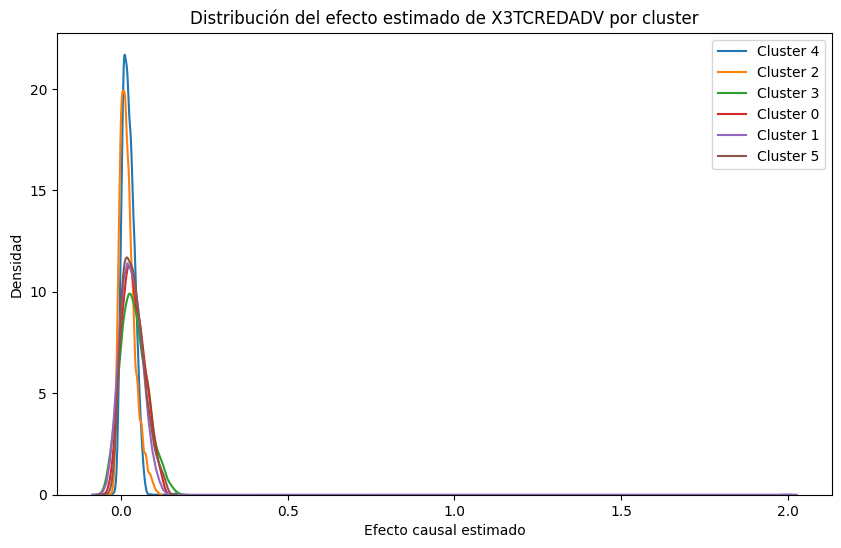

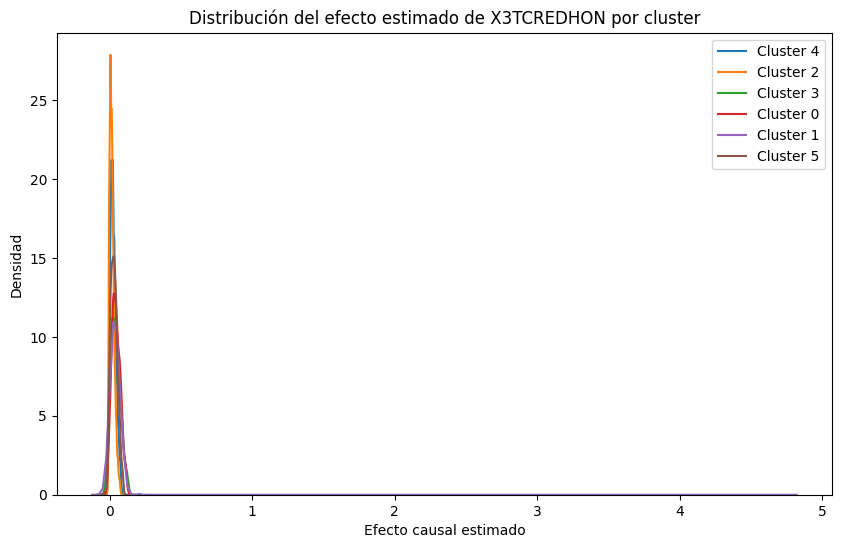

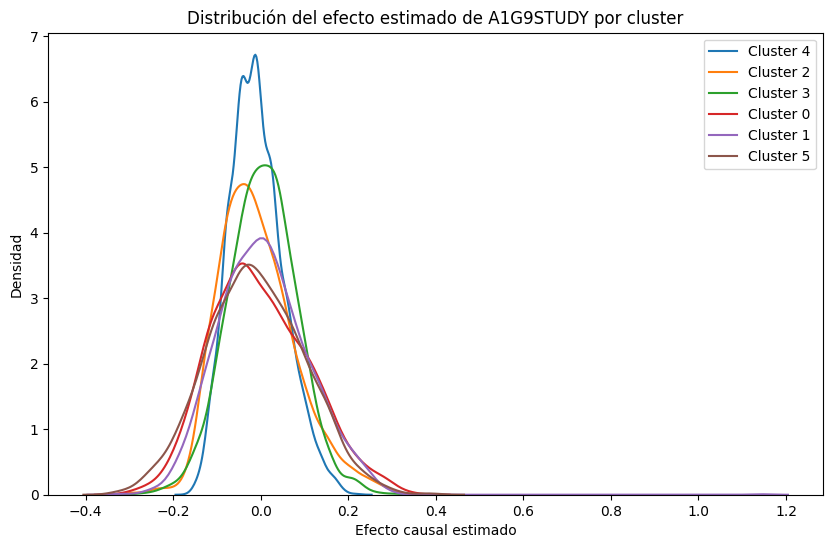

In [169]:
for treatment_name in tratamiento:
    plt.figure(figsize=(10,6))
    for c in clusters:
        sns.kdeplot(effects_clusters[c][treatment_name], label=f'Cluster {c}')
    plt.title(f'Distribución del efecto estimado de {treatment_name} por cluster')
    plt.xlabel('Efecto causal estimado')
    plt.ylabel('Densidad')
    plt.legend()
    plt.show()


# Guardar resultados

In [170]:
for i, treatment_name in enumerate(tratamiento):
    effect_col = f'effect_{treatment_name}'
    df_clustered[effect_col] = np.nan  # inicializamos

for c in clusters:
    idx = df_clustered['Cluster'] == c
    for i, treatment_name in enumerate(tratamiento):
        df_clustered.loc[idx, f'effect_{treatment_name}'] = effects_clusters[c][treatment_name]




# Descargar el archivo
from google.colab import files
df_clustered.to_csv("effects_per_cluster.csv", index=False)
files.download("effects_per_cluster.csv")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Resumen de lo que se guardó:

Cluster -- asignación del cluster

effect_X3TCREDADV -- efecto estimado de créditos avanzados

effect_X3TCREDHON -- efecto estimado de créditos honors

effect_A1G9STUDY -- efecto estimado del taller de estudio

Variables originales (para poder relacionar efectos con otras características)